# Target Column - Temporal Mean of Colony Collapse 

We want to add a few columns to the pathogen data which is in quarterly_aphis_df. The data will come from two sources: the NASS ldata set, which qives quarterly loss from 2015-2024 and the BIP data acquired through APHIS, which gives seasonal loss staring in 2009 - Q3 of 2023. 

1. Average/median quarterly loss for a given state considering a rolling window of T = 5 years
2. New Target variable Y = 1 if the current loss > avg/median quarterly loss and 0 otherwise.

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [76]:
bee_df = pd.read_csv("../data/interim/bee_df.csv", na_values=["NaN"])

In [77]:
bee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 18 columns):
 #   Column                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                 --------------  -----  
 0   Year                                                                                                   4035 non-null   int64  
 1   Period                                                                                                 4035 non-null   object 
 2   State                                                                                                  4035 non-null   object 
 3   HONEY, BEE COLONIES - ADDED & REPLACED, MEASURED IN COLONIES                                           1817 non-null   object 
 4   HONEY, BEE COLONIES - INVENTORY, MAX, MEASURED IN COLONIES                                      

In [78]:
# Restrict to the columns which include loss 
bee_loss_df=bee_df[['Year', 'Period', 'State', 'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN COLONIES','HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES']].copy()
bee_loss_df.columns=['year', 'period', 'state', 'loss', 'percent loss']

bee_loss_df.head(10)


,year,period,state,loss,percent loss
0,2015,FIRST OF APR,ALABAMA,NaN,NaN
1,2015,FIRST OF APR,ARIZONA,NaN,NaN
2,2015,FIRST OF APR,ARKANSAS,NaN,NaN
3,2015,FIRST OF APR,CALIFORNIA,NaN,NaN
4,2015,FIRST OF APR,COLORADO,NaN,NaN
5,2015,FIRST OF APR,CONNECTICUT,NaN,NaN
6,2015,FIRST OF APR,FLORIDA,NaN,NaN
7,2015,FIRST OF APR,GEORGIA,NaN,NaN
8,2015,FIRST OF APR,HAWAII,NaN,NaN
9,2015,FIRST OF APR,IDAHO,NaN,NaN


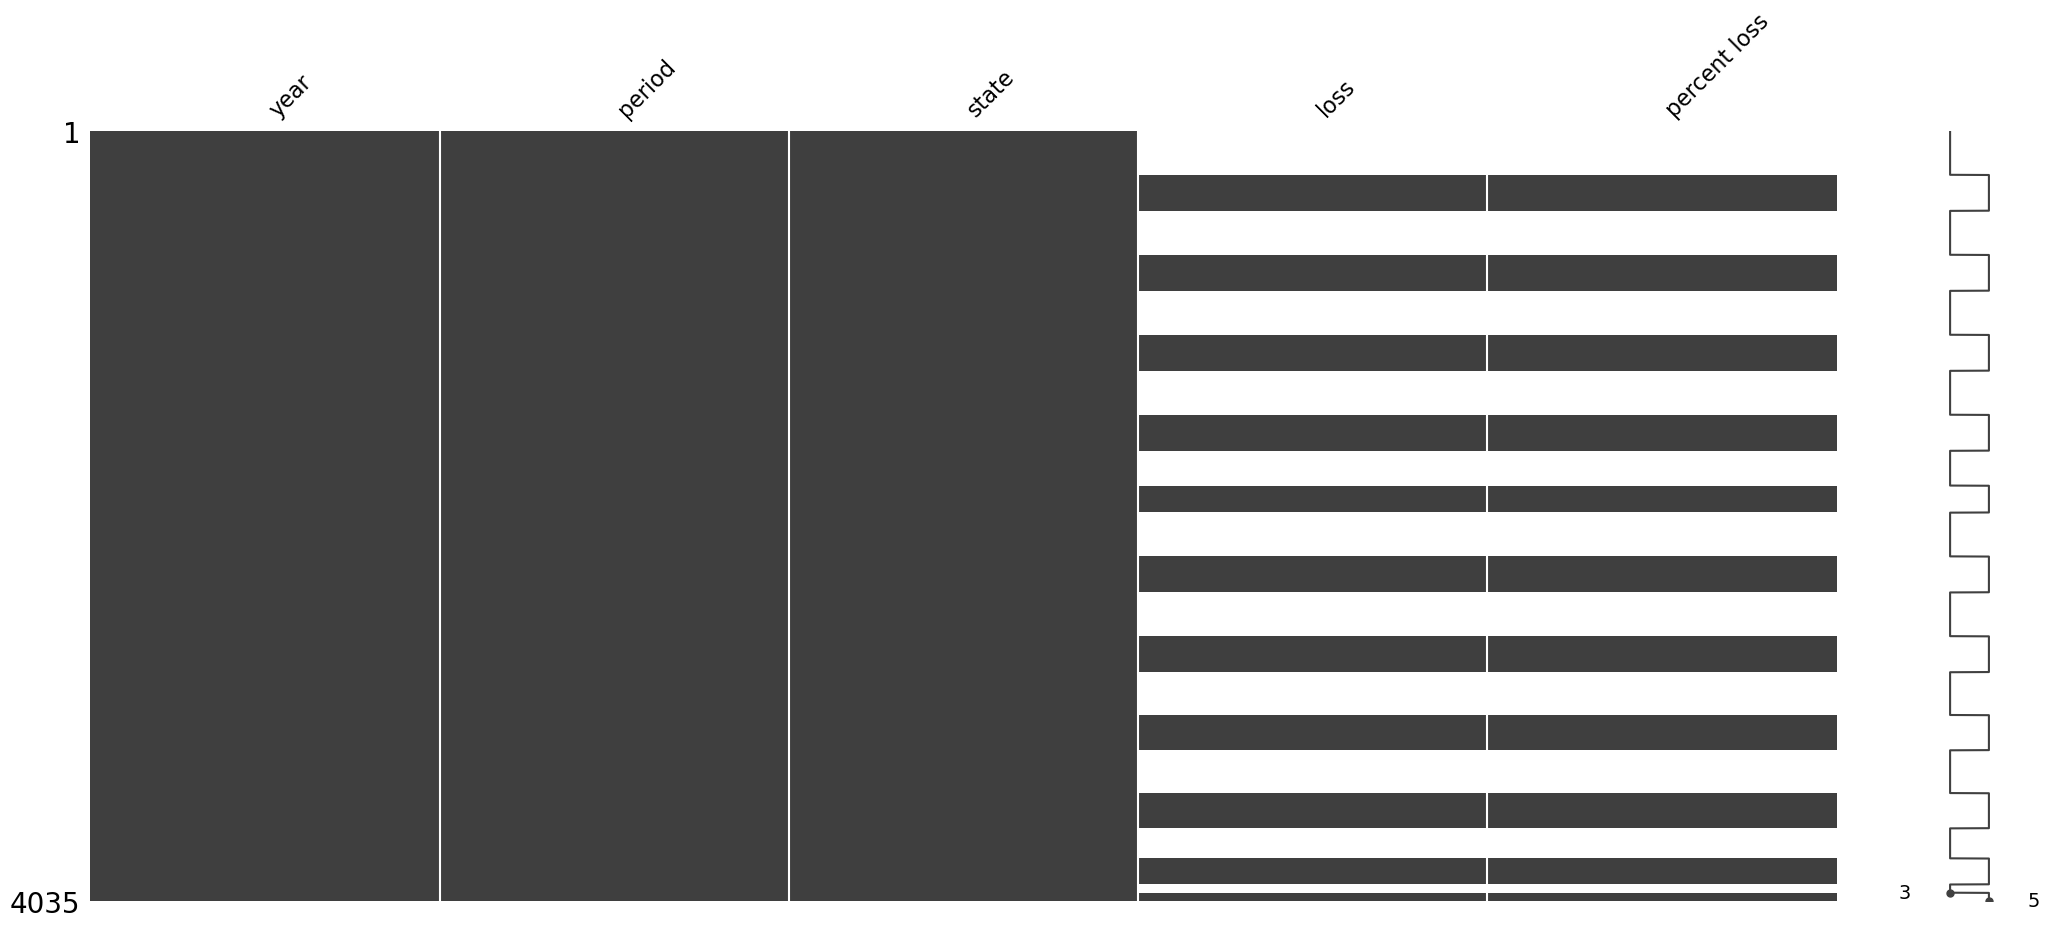

In [79]:
import missingno as msno
msno.matrix(bee_loss_df)
plt.show()

I think it's the case that the Q1-Q4 data contains colony loss numbers while the "First of..." periods do not. Let's double check. 

In [80]:
bee_loss_df['Numeric_or_NaN'] = bee_loss_df.apply(
    lambda row: all(pd.to_numeric(row[['loss', 'percent loss']], errors='coerce').notna())
                if row['period'] in ['FIRST OF JAN', 'FIRST OF APR', 'FIRST OF JUL', 'FIRST OF OCT', 'MARKETING YEAR', 'YEAR']
                else True,
    axis=1
)

In [81]:
bee_loss_df.sample(25)

,year,period,state,loss,percent loss,Numeric_or_NaN
2829,2021,Q4,VERMONT,40,1,True
1542,2018,Q2,HAWAII,380,2,True
3445,2023,MARKETING YEAR,MISSISSIPPI,NaN,NaN,False
1495,2018,Q1,HAWAII,"1,600",9,True
3776,2024,FIRST OF OCT,MONTANA,NaN,NaN,False
3232,2022,Q4,SOUTH CAROLINA,"1,700",11,True
2435,2021,FIRST OF APR,MASSACHUSETTS,NaN,NaN,False
1504,2018,Q1,MARYLAND,"1,600",20,True
2429,2021,FIRST OF APR,IOWA,NaN,NaN,False
2881,2022,FIRST OF JAN,ALABAMA,NaN,NaN,False


In [82]:
bee_loss_nan = bee_loss_df[bee_loss_df['Numeric_or_NaN']==False]
print(bee_loss_nan.iloc[:, 0].isin(['Q1', 'Q2', 'Q3', 'Q4']).any())


False


Great, there are no rows of qarterly data that are NaN. We can proceed by including only the quarterly data. 

In [83]:
bee_loss_df=bee_loss_df[bee_loss_df['period'].isin(['Q1', 'Q2', 'Q3', 'Q4'])]

In [84]:
bee_loss_df.sample(20)

,year,period,state,loss,percent loss,Numeric_or_NaN
3835,2024,Q1,NEW JERSEY,"1,200",7,True
1959,2019,Q4,GEORGIA,"20,000",15,True
387,2015,Q4,MAINE,60,1,True
3216,2022,Q4,MICHIGAN,"5,500",8,True
3510,2023,Q1,VIRGINIA,"1,200",11,True
3142,2022,Q2,TENNESSEE,"4,400",38,True
1250,2017,Q4,VERMONT,470,7,True
1635,2018,Q4,GEORGIA,"19,500",12,True
832,2016,Q4,VIRGINIA,730,10,True
3171,2022,Q3,MINNESOTA,"7,500",7,True


In [85]:
bee_loss_df = bee_loss_df[bee_loss_df['state'] != 'OTHER STATES']
bee_loss_df = bee_loss_df[bee_loss_df['state'] != 'US TOTAL']
bee_loss_df = bee_loss_df.drop(columns=['Numeric_or_NaN'], axis=1)

In [86]:

bee_loss_df.sample(25)

,year,period,state,loss,percent loss
807,2016,Q4,MARYLAND,500,5
1198,2017,Q3,SOUTH DAKOTA,"16,500",10
1179,2017,Q3,MARYLAND,"1,600",19
2234,2020,Q1,CONNECTICUT,330,9
3819,2024,Q1,IDAHO,"23,000",12
342,2015,Q3,MASSACHUSETTS,560,8
1884,2019,Q1,NEW MEXICO,170,4
1644,2018,Q4,MAINE,"1,400",12
1581,2018,Q3,ALABAMA,"1,700",20
1969,2019,Q4,MARYLAND,"1,100",14


NEED TO figure out what  (Z) means (not zero since for examples WY in Q3 2023 lost 860 colonies) 

## Include pre-2015 Data

Load loss data from the BIP (available on the APHIS website: https://www.usbeedata.org/loss-map/) 


In [87]:
bip_raw_df = pd.read_csv('../data/raw/aphis/LMS2022_States_Loss.csv', na_values=["[R]"])

In [88]:
bip_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 7488 non-null   object 
 1   state                 7488 non-null   object 
 2   initials              7488 non-null   object 
 3   SurveyYear            7488 non-null   int64  
 4   Season                7488 non-null   object 
 5   Method                7488 non-null   object 
 6   OT                    7488 non-null   object 
 7   N                     7488 non-null   int64  
 8   b.rep                 7488 non-null   int64  
 9   b.method              7488 non-null   object 
 10  TL.b.mean             4040 non-null   float64
 11  TL.b.025perc          4040 non-null   float64
 12  TL.b.975perc          4040 non-null   float64
 13  AL.b.mean             4040 non-null   float64
 14  AL.b.025perc          4040 non-null   float64
 15  AL.b.975perc         

In [89]:
bip_df=bip_raw_df[['initials', 'SurveyYear', 'Season', 'Method','TotalColAtRisk', 'TotalColLost', 'TotalColAlive']].copy()
bip_df=bip_df[bip_df['Season'].isin(['Summer', 'Winter'])]
bip_df = bip_df[bip_df['Method']== 'MSO out'] # remove data for multistate operations
bip_df = bip_df[bip_df['initials']!= 'NCUSA' ]

In [90]:
bip_df.sample(25)

,initials,SurveyYear,Season,Method,TotalColAtRisk,TotalColLost,TotalColAlive
7480,VT,2023,Winter,MSO out,694,188.0,506.0
6023,UT,2014,Summer,MSO out,254,34.0,220.0
5049,CO,2008,Summer,MSO out,0,0.0,0.0
6959,UT,2020,Summer,MSO out,650,189.0,461.0
6792,NC,2019,Summer,MSO out,1585,264.0,1321.0
5737,LA,2012,Winter,MSO out,3446,335.0,3111.0
7268,SD,2022,Summer,MSO out,75,17.0,58.0
5273,MI,2009,Winter,MSO out,6143,709.0,5434.0
6147,ID,2015,Summer,MSO out,244,33.0,211.0
6539,SC,2017,Winter,MSO out,474,131.0,343.0


In [91]:
bip_df = bip_df.drop(columns=['Method'], axis=1)

Calculate the percent lost at each season. 

In [ ]:
bip_df['percent loss']=bip_df['TotalColLost']/bip_df['TotalColAtRisk']

Now we need to estimate the loss for each quarter. Here we will need to make some assumptions and the following note: 

Consider if the loss were 10% for each or Q2 and Q3. That is, if you start will 100 colonies, at the end of Q2 you have 90 and then by the end of Q3 you have 81 (since you lost 10% of the now available colonies). This means that the overall loss for the summer would be 19%. 

We will make the assumption that the loss is the same across the two quarters in question and use the quadriatic formula to determine the quarterly loss. 

quarterly_loss = 1-\sqrt(1-seasonal_loss)

Also note that Winter refers to October through March (Q4 and Q1) and Summer refers to April through September (Q2 and Q3). Winter 2010 would include Q4 for 2010 and Q1 for 2011. 


In [19]:
bip_df.sample(10)

,initials,SurveyYear,Season,TotalColAtRisk,TotalColLost,TotalColAlive,percent loss
7248,MA,2022,Summer,1228,192.0,1036.0,0.156352
6049,LA,2014,Winter,2333,576.0,1757.0,0.246892
6621,LA,2018,Summer,172,41.0,131.0,0.238372
6296,CA,2016,Summer,26826,4461.0,22365.0,0.166294
6921,CO,2020,Summer,552,135.0,417.0,0.244565
6043,ID,2014,Winter,8086,1033.0,7053.0,0.127752
6657,AK,2018,Winter,0,0.0,0.0,NaN
5984,CA,2014,Summer,25023,4769.0,20254.0,0.190585
5980,AL,2014,Summer,347,74.0,273.0,0.213256
6664,DE,2018,Winter,128,65.0,63.0,0.507812


In [93]:
def expand_to_quarters(df):
    """
    Expand seasonal loss data into quarterly rows. 

    Parameters
    ----------
    df : pd.DataFrame
        Columns: ['initials', 'SurveyYear', 'Season', 'percent loss']

    Returns
    -------
    pd.DataFrame
        Columns: ['state', 'year', 'quarter', 'loss_quarter']
    """

    rows = []

    for _, row in df.iterrows():
        state = row['initials']
        year = row['SurveyYear']
        season = row['Season']
        loss = row['percent loss']
        loss_quarter = 1 - np.sqrt(loss)
        
        if season == 'Summer':
            quarters = ['Q2', 'Q3']
            years = [year, year]
        elif season == 'Winter':
            quarters = ['Q4', 'Q1']
            years = [year, year + 1]
        else:
            continue  # skip unknown seasons

        for q, y in zip(quarters, years):
            rows.append({
                'state_code': state, 
                'year': y,
                'quarter': q,
                'loss_quarter': loss_quarter,
            })

    return pd.DataFrame(rows)


In [94]:
quarterly_bip_df = expand_to_quarters(bip_df)
quarterly_bip_df.sample(10)

,state_code,year,quarter,loss_quarter
85,TX,2008,Q3,NaN
2981,ID,2023,Q1,0.383464
2467,FL,2020,Q3,0.584302
1098,SC,2013,Q2,0.659849
1309,TX,2014,Q3,0.454722
1982,MN,2017,Q4,0.477694
1572,MI,2015,Q4,0.535292
1033,CT,2013,Q3,0.657812
1966,IA,2017,Q4,0.309302
1749,DC,2017,Q1,NaN


Note: year above corresponds to the year of the quarter now. 

In [59]:
quarterly_aphis_df=pd.read_csv('../data/interim/quarterly_aphis_df.csv')

In [95]:
quarterly_aphis_df.sample(10)

,sample_year,state_code,region,quarter,mean_varroa,max_varroa,nosema,abpv,amsv1,cbpv,dwv,dwvb,iapv,kbv,lsv2,bip_loss_prev5yrs_list,bip_mean_loss_prev5yrs,nass_mean_loss_prev5yrs
688,2022,MD,Northeast,Q3,2.692941,9.21,0.147059,70.000000,0.0,50.000000,40.000000,58.125000,70.000000,0.0,0.000000,"[0.4811842798697624, 0.49621317048711644, 0.58...",0.517479,0.104
377,2018,WV,Ohio Valley,Q3,2.452500,9.30,0.118750,30.000000,0.0,0.000000,55.000000,39.000000,35.000000,0.0,60.000000,"[0.7278344730240913, 0.7244404312438489, 0.737...",0.694852,0.056667
403,2019,IN,Ohio Valley,Q4,8.068000,18.15,0.010000,85.000000,0.0,60.000000,48.000000,56.000000,30.000000,0.0,60.000000,"[0.18988669554314674, 0.33089705966131455, 0.4...",0.359297,0.195
669,2022,FL,Southeast,Q4,3.958000,18.28,0.186667,65.555556,0.0,40.000000,61.428571,70.000000,60.000000,0.0,53.750000,"[0.5146929795869115, 0.4703450640794158, 0.381...",0.403315,0.136
356,2018,SD,Northern Rockies & Plains,Q4,10.028750,48.03,0.387500,65.000000,0.0,80.000000,55.000000,61.250000,53.333333,0.0,70.000000,<NA>,0.397442,0.06
107,2016,IL,Ohio Valley,Q3,3.113810,7.48,0.085714,52.500000,0.0,63.333333,72.631579,65.000000,73.333333,90.0,62.000000,"[0.6358345328628796, 0.559330506562477, 0.5972...",0.596794,0.1
709,2022,NY,Northeast,Q2,1.003750,2.56,0.881250,0.000000,70.0,0.000000,42.500000,38.750000,32.500000,0.0,33.333333,"[0.5010263851915313, 0.6386323310272888, 0.678...",0.576398,0.055
925,2024,UT,Southwest,Q2,0.268571,1.25,1.707143,0.000000,0.0,30.000000,40.000000,42.857143,46.000000,0.0,66.666667,"[0.5727228189176443, 0.46076977943624975, 0.34...",0.449935,0.1425
803,2023,NM,Southwest,Q3,3.835000,6.48,0.000000,0.000000,0.0,30.000000,70.000000,70.000000,0.000000,0.0,0.000000,"[0.26685608506924097, 0.6699834987623969, 0.36...",0.448565,0.104
456,2019,VA,Southeast,Q4,9.875714,21.29,0.364286,70.000000,0.0,43.333333,48.571429,54.285714,50.000000,0.0,60.000000,"[0.42557748938192586, 0.39771100461799935, 0.4...",0.379439,0.12


Fill in missing data with regional average over the previous 5 years. If there is not data give, we will take a regional average. 

In [96]:
def historic_loss_with_fill(quarterly_aphis_df, quarterly_bip_df, window=5):
    quarterly_aphis_df = quarterly_aphis_df.copy()

    # Build a column of lists of matching losses (so that we can later inspect) 
    loss_lists = []
    for _, row in quarterly_aphis_df.iterrows():
        state = row['state_code']
        quarter = row['quarter']
        year = row['sample_year']

        mask = (
            (quarterly_bip_df['state_code'] == state) &
            (quarterly_bip_df['quarter'] == quarter) &
            (quarterly_bip_df['year'].between(year - window, year - 1))
        )

        matches = quarterly_bip_df.loc[mask, 'loss_quarter'].dropna()

        loss_lists.append(matches.tolist() if not matches.empty else pd.NA)

    quarterly_aphis_df['bip_loss'] = quarterly_bip_df['loss_quarter']

    quarterly_aphis_df['bip_loss_prev5yrs_list'] = loss_lists

    # Compute mean from list (if list exists)
    def mean_from_list(x):
        if isinstance(x, list) and len(x) > 0:
            return sum(x) / len(x)
        return pd.NA

    quarterly_aphis_df['bip_mean_loss_prev5yrs'] = quarterly_aphis_df['bip_loss_prev5yrs_list'].apply(mean_from_list)

    # Fill NaNs using the regional mean (per quarter)
    # First compute the regional mean ignoring NaNs
    region_means = (
        quarterly_aphis_df.groupby(['region', 'quarter'])['bip_mean_loss_prev5yrs']
        .transform(lambda x: pd.to_numeric(x, errors='coerce').fillna(x.mean()))
    )

    quarterly_aphis_df['bip_mean_loss_prev5yrs'] = (
        pd.to_numeric(quarterly_aphis_df['bip_mean_loss_prev5yrs'], errors='coerce')
        .fillna(region_means)
        .astype(float)
    )   

    return quarterly_aphis_df


In [97]:
quarterly_aphis_df = historic_loss_with_fill(quarterly_aphis_df, quarterly_bip_df, window=5)

In [98]:
quarterly_aphis_df.sample(10)

,sample_year,state_code,region,quarter,mean_varroa,max_varroa,nosema,abpv,amsv1,cbpv,dwv,dwvb,iapv,kbv,lsv2,bip_loss_prev5yrs_list,bip_mean_loss_prev5yrs,nass_mean_loss_prev5yrs,bip_loss
603,2021,MT,Northern Rockies & Plains,Q4,1.175000,1.72,0.000000,0.0,0.0,0.0,55.000000,65.000000,65.000000,0.0,50.000000,"[0.4522774424948339, 0.4714058601290756, 0.503...",0.475018,0.106,0.425070
330,2018,ND,Northern Rockies & Plains,Q3,4.120556,16.50,0.277778,0.0,0.0,90.0,45.333333,58.823529,76.000000,30.0,62.500000,<NA>,0.599739,0.14,NaN
352,2018,SC,Southeast,Q1,1.300000,2.41,0.030000,40.0,0.0,0.0,44.000000,42.000000,56.666667,0.0,53.333333,"[0.4930884546835014, 0.37558416241507553, 0.45...",0.453470,0.15,0.506152
628,2021,TX,South,Q2,0.060000,0.12,0.650000,0.0,0.0,0.0,40.000000,45.000000,50.000000,0.0,60.000000,"[0.44108789670288273, 0.6175095582566231, 0.57...",0.538340,0.0975,NaN
507,2020,MN,Upper Midwest,Q3,7.600000,26.90,0.028571,47.5,0.0,0.0,40.000000,61.428571,0.000000,0.0,45.000000,"[0.6492459677107155, 0.30568688110427644, 0.56...",0.507597,0.194,NaN
455,2019,VA,Southeast,Q3,3.260000,6.09,0.418750,40.0,0.0,45.0,51.250000,61.250000,40.000000,0.0,70.000000,"[0.6061529338040524, 0.6118105632718243, 0.574...",0.582109,0.0925,NaN
360,2018,TX,South,Q3,0.954000,2.88,0.000000,0.0,0.0,0.0,37.500000,30.000000,0.000000,0.0,0.000000,"[0.731866777820052, 0.4547217646730368, 0.4519...",0.539431,0.11,NaN
12,2015,FL,Southeast,Q4,7.196667,28.17,0.283333,54.0,0.0,0.0,68.000000,0.000000,30.000000,0.0,43.333333,"[0.3279468919907065, 0.3617040466957051, 0.543...",0.471022,<NA>,NaN
70,2015,VT,Northeast,Q2,5.435000,8.05,0.775000,0.0,0.0,30.0,85.000000,0.000000,0.000000,0.0,75.000000,"[0.7939149630103086, 0.7202485575279058, 0.738...",0.700568,<NA>,NaN
95,2016,GA,Southeast,Q3,2.998333,12.24,0.041667,44.0,0.0,0.0,75.294118,50.833333,45.000000,0.0,60.000000,"[0.4947532666079121, 0.6522625916264664, 0.637...",0.603972,0.12,NaN


## Include NASS data:
Now we will incorporate the NASS data, starting with adding a column for loss. 

In [101]:
bee_df = pd.read_csv("../data/interim/bee_data_cleaned.csv")

In [102]:
bee_df.sample(10)

,Year,Period,State,"HONEY, BEE COLONIES - ADDED & REPLACED, MEASURED IN COLONIES","HONEY, BEE COLONIES - INVENTORY, MAX, MEASURED IN COLONIES",COLONIES AT FIRST OF QUARTER,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN COLONIES","HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY DISEASE - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY OTHER CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTICIDES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTS ((EXCL VARROA MITES)) - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY UNKNOWN CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY VARROA MITES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN PCT OF COLONIES"
422,2017,Q2,HAWAII,"3,000","12,000",12000,70,1.0,0.05,0.4,0.0,3.70,0.0,88.9,920,8.0
177,2015,Q4,UTAH,120,"28,000",28000,"1,900",7.0,6.40,4.4,0.2,9.10,0.4,75.8,100,0.0
328,2016,Q4,FLORIDA,"31,000","300,000",255000,"41,000",14.0,7.70,13.6,17.0,27.10,6.5,30.9,"11,500",4.0
1137,2021,Q2,OTHER STATES,"2,880","8,460",6020,140,2.0,0.05,5.7,4.6,0.05,4.7,42.8,"3,130",37.0
1555,2023,Q3,WISCONSIN,"1,500","59,000",59000,"7,000",12.0,0.90,0.8,7.4,1.20,2.2,54.9,"3,400",6.0
814,2019,Q3,OREGON,"6,000","118,000",83000,"8,000",7.0,19.80,16.6,15.1,12.80,0.4,35.4,"21,000",18.0
79,2015,Q2,OTHER STATES,"4,140","11,200",8600,"1,940",17.0,0.00,0.1,0.0,9.10,0.0,36.3,"1,960",18.0
1341,2022,Q3,ILLINOIS,730,"12,500",12500,"1,100",9.0,0.70,1.4,11.8,20.10,10.0,37.4,770,6.0
19,2015,Q1,MICHIGAN,"7,500","60,000",16500,"11,500",19.0,1.10,8.3,1.6,3.10,4.6,14.3,"2,400",4.0
483,2017,Q3,MONTANA,"3,100","161,000",154000,"18,500",11.0,6.90,19.1,2.2,6.70,2.0,42.3,"23,000",14.0


In [103]:
quarterly_aphis_df.sample(10)

,sample_year,state_code,region,quarter,mean_varroa,max_varroa,nosema,abpv,amsv1,cbpv,dwv,dwvb,iapv,kbv,lsv2,bip_loss_prev5yrs_list,bip_mean_loss_prev5yrs,nass_mean_loss_prev5yrs,bip_loss
15,2015,HI,Hawaii,Q1,0.900000,3.56,0.675000,30.000000,0.0,30.000000,30.000000,0.000000,30.000000,0.0,0.000000,<NA>,NaN,<NA>,NaN
942,2024,WY,Northern Rockies & Plains,Q3,1.641250,4.15,0.368750,0.000000,0.0,30.000000,62.500000,68.750000,66.666667,50.0,60.000000,[0.5603668450578713],0.560367,0.0821,0.417478
1,2015,AL,Southeast,Q3,4.143000,12.09,0.090000,90.000000,0.0,0.000000,61.250000,0.000000,0.000000,40.0,30.000000,"[0.7091785523248659, 0.5048497751452139, 0.603...",0.588855,<NA>,NaN
505,2020,MI,Upper Midwest,Q4,5.402500,18.55,0.290000,73.076923,0.0,47.500000,71.000000,71.000000,63.846154,40.0,60.000000,"[0.5352922344171596, 0.36145532064260255, 0.35...",0.374983,0.106,NaN
73,2015,WI,Upper Midwest,Q3,13.063846,47.39,0.188462,30.000000,0.0,46.666667,66.153846,0.000000,62.500000,40.0,40.000000,"[0.596972781035177, 0.5791094596451856, 0.5821...",0.594074,<NA>,NaN
854,2024,AR,South,Q3,4.034000,18.50,0.060000,44.285714,30.0,50.000000,65.714286,73.333333,90.000000,0.0,30.000000,"[0.5299442788855975, 0.5437962873768261, 0.390...",0.525912,0.094,0.564174
643,2021,WI,Upper Midwest,Q2,0.168000,0.42,0.560000,0.000000,0.0,0.000000,30.000000,34.000000,43.333333,0.0,46.666667,"[0.6144703298326177, 0.5271789352795963, 0.459...",0.532064,0.07,NaN
662,2022,CO,Southwest,Q2,0.521538,3.09,1.538462,0.000000,0.0,0.000000,31.666667,40.769231,55.000000,0.0,34.000000,"[0.5306254161120354, 0.5145206124970538, 0.568...",0.516323,0.17,0.550987
636,2021,VA,Southeast,Q4,5.310000,7.52,0.075000,60.000000,0.0,55.000000,67.500000,75.000000,30.000000,0.0,30.000000,"[0.4203399005418864, 0.42580295083405495, 0.22...",0.392871,0.13,0.635835
600,2021,MN,Upper Midwest,Q4,0.705000,0.75,0.025000,0.000000,0.0,0.000000,35.000000,45.000000,0.000000,0.0,30.000000,"[0.3602341232588967, 0.47769352478257165, 0.18...",0.308009,0.114,0.384626


In [104]:
bee_df['nass_loss_percent']=bee_df['HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES']/100

bee_df = bee_df.rename(columns={
    'Year': 'sample_year',
    'Period': 'quarter'
})

In [105]:
# replace state names in bee_df with state_codes so that we can merge data

import us
bee_df["state_code"] = bee_df["State"].map(lambda x: us.states.lookup(x).abbr if us.states.lookup(x) else None)


In [106]:
# average over the past 5 years of the BIP data (for a given quarter) 
def add_nass_loss(quarterly_aphis_df, bee_df, window=5):
    results = []

    for _, row in quarterly_aphis_df.iterrows():
        state = row['state_code']
        quarter = row['quarter']
        year = row['sample_year']

        # filter the loss data for same state and quarter, and previous 5 years AS AVAILABLE -- does a shorter average for unavailable data
        mask = (
            (bee_df['state_code'] == state) &
            (bee_df['quarter'] == quarter) &
            (bee_df['sample_year'].between(year - window, year - 1))
        )

        matches = bee_df.loc[mask, 'nass_loss_percent']

        if not matches.empty:
            avg_loss = matches.mean()  # or .tolist() if you want all values
        else:
            avg_loss = pd.NA

        results.append(avg_loss)

    quarterly_aphis_df = quarterly_aphis_df.copy()
    quarterly_aphis_df['nass_mean_loss_prev5yrs'] = results
    return quarterly_aphis_df

In [107]:
quarterly_aphis_df = add_nass_loss(quarterly_aphis_df, bee_df, window=5)

In [108]:
bee_df.sample(10)


,sample_year,quarter,State,"HONEY, BEE COLONIES - ADDED & REPLACED, MEASURED IN COLONIES","HONEY, BEE COLONIES - INVENTORY, MAX, MEASURED IN COLONIES",COLONIES AT FIRST OF QUARTER,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN COLONIES","HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY DISEASE - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY OTHER CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTICIDES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTS ((EXCL VARROA MITES)) - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY UNKNOWN CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY VARROA MITES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN PCT OF COLONIES",nass_loss_percent,state_code
1598,2023,Q4,WASHINGTON,40,"92,000",80000,"19,000",21.0,6.90,8.9,0.90,1.2,24.20,46.5,"1,700",2.00,0.21,WA
213,2016,Q1,NORTH DAKOTA,"4,600","137,000",89000,"8,500",6.0,0.00,0.1,0.00,0.0,11.70,2.7,0,0.00,0.06,ND
1009,2020,Q3,WEST VIRGINIA,210,"8,000",8000,540,7.0,4.70,1.7,4.70,10.1,2.60,17.7,800,10.00,0.07,WV
88,2015,Q2,WASHINGTON,"15,000","127,000",105000,"5,000",4.0,2.20,3.2,2.00,0.2,0.50,48.7,"13,000",10.00,0.04,WA
1722,2024,Q4,MONTANA,"1,000","99,000",95000,"15,500",16.0,1.80,9.8,18.50,0.0,0.70,25.8,0,0.00,0.16,MT
85,2015,Q2,UTAH,"10,000","27,000",24000,"3,400",13.0,1.50,5.6,12.30,10.8,1.20,27.2,"3,900",14.00,0.13,UT
400,2017,Q1,OREGON,"7,500","90,000",71000,"8,000",9.0,10.10,15.4,9.10,8.5,8.50,28.7,"1,400",2.00,0.09,OR
1745,2025,Q1,NORTH CAROLINA,"4,000","28,000",24000,"2,500",9.0,0.05,2.3,0.05,3.2,4.50,6.0,"4,600",16.00,0.09,NC
1412,2022,Q4,SOUTH DAKOTA,20,"175,000",175000,"27,000",15.0,5.00,9.4,11.40,30.7,0.05,67.1,10,0.05,0.15,SD
1508,2023,Q2,WASHINGTON,"18,500","123,000",87000,"4,400",4.0,6.10,4.3,9.20,1.0,0.05,41.6,"15,500",13.00,0.04,WA


In [109]:
merged_df = pd.merge(
    quarterly_aphis_df,
    bee_df,
    on=['sample_year', 'quarter', 'state_code'],
    how='left'
)

In [110]:
merged_df.sample(10)

,sample_year,state_code,region,quarter,mean_varroa,max_varroa,nosema,abpv,amsv1,cbpv,...,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY DISEASE - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY OTHER CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTICIDES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTS ((EXCL VARROA MITES)) - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY UNKNOWN CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY VARROA MITES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN PCT OF COLONIES",nass_loss_percent
342,2018,OH,Ohio Valley,Q4,6.275000,14.90,0.290000,80.0,0.0,0.000000,...,14.0,0.1,2.4,8.1,5.8,9.90,29.3,450,3.0,0.14
230,2017,MT,Northern Rockies & Plains,Q4,2.910000,2.91,0.000000,0.0,0.0,0.000000,...,11.0,3.1,5.3,5.9,4.1,4.10,54.2,"2,900",2.0,0.11
774,2023,IN,Ohio Valley,Q4,4.203333,8.77,0.150000,55.0,0.0,55.000000,...,27.0,5.8,2.0,8.4,32.8,0.05,47.5,620,4.0,0.27
521,2020,OR,Northwest,Q2,1.903750,5.65,0.175000,0.0,0.0,0.000000,...,3.0,7.5,5.9,2.2,1.7,0.70,28.0,"19,000",20.0,0.03
12,2015,FL,Southeast,Q4,7.196667,28.17,0.283333,54.0,0.0,0.000000,...,14.0,2.5,3.0,6.8,18.4,4.20,27.3,"28,000",11.0,0.14
18,2015,HI,Hawaii,Q4,0.000000,0.00,0.562500,65.0,0.0,0.000000,...,5.0,0.2,0.0,0.0,33.9,0.00,31.0,760,6.0,0.05
62,2015,TX,South,Q3,3.480000,6.77,0.008333,47.5,0.0,30.000000,...,12.0,1.3,4.7,19.4,26.0,5.20,30.7,"4,800",4.0,0.12
80,2016,CA,West,Q2,0.415556,1.19,0.700000,30.0,0.0,86.666667,...,9.0,11.2,15.3,14.2,14.1,2.60,49.7,"185,000",16.0,0.09
388,2019,CA,West,Q3,2.688235,9.11,0.229412,50.0,0.0,30.000000,...,13.0,8.7,11.1,16.0,11.5,3.20,49.0,"108,000",15.0,0.13
659,2022,CA,West,Q2,1.179615,5.35,0.573077,30.0,0.0,35.000000,...,10.0,4.8,20.3,6.6,16.2,3.70,41.1,"120,000",12.0,0.10


In [111]:
merged_df.columns

Index(['sample_year', 'state_code', 'region', 'quarter', 'mean_varroa',
       'max_varroa', 'nosema', 'abpv', 'amsv1', 'cbpv', 'dwv', 'dwvb', 'iapv',
       'kbv', 'lsv2', 'bip_loss_prev5yrs_list', 'bip_mean_loss_prev5yrs',
       'nass_mean_loss_prev5yrs', 'bip_loss', 'State',
       'HONEY, BEE COLONIES - ADDED & REPLACED, MEASURED IN COLONIES',
       'HONEY, BEE COLONIES - INVENTORY, MAX, MEASURED IN COLONIES',
       'COLONIES AT FIRST OF QUARTER',
       'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN COLONIES',
       'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES',
       'HONEY, BEE COLONIES, AFFECTED BY DISEASE - INVENTORY, MEASURED IN PCT OF COLONIES',
       'HONEY, BEE COLONIES, AFFECTED BY OTHER CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES',
       'HONEY, BEE COLONIES, AFFECTED BY PESTICIDES - INVENTORY, MEASURED IN PCT OF COLONIES',
       'HONEY, BEE COLONIES, AFFECTED BY PESTS ((EXCL VARROA MITES)) - INVENTORY, MEASURED IN PCT OF COLONIES',
  

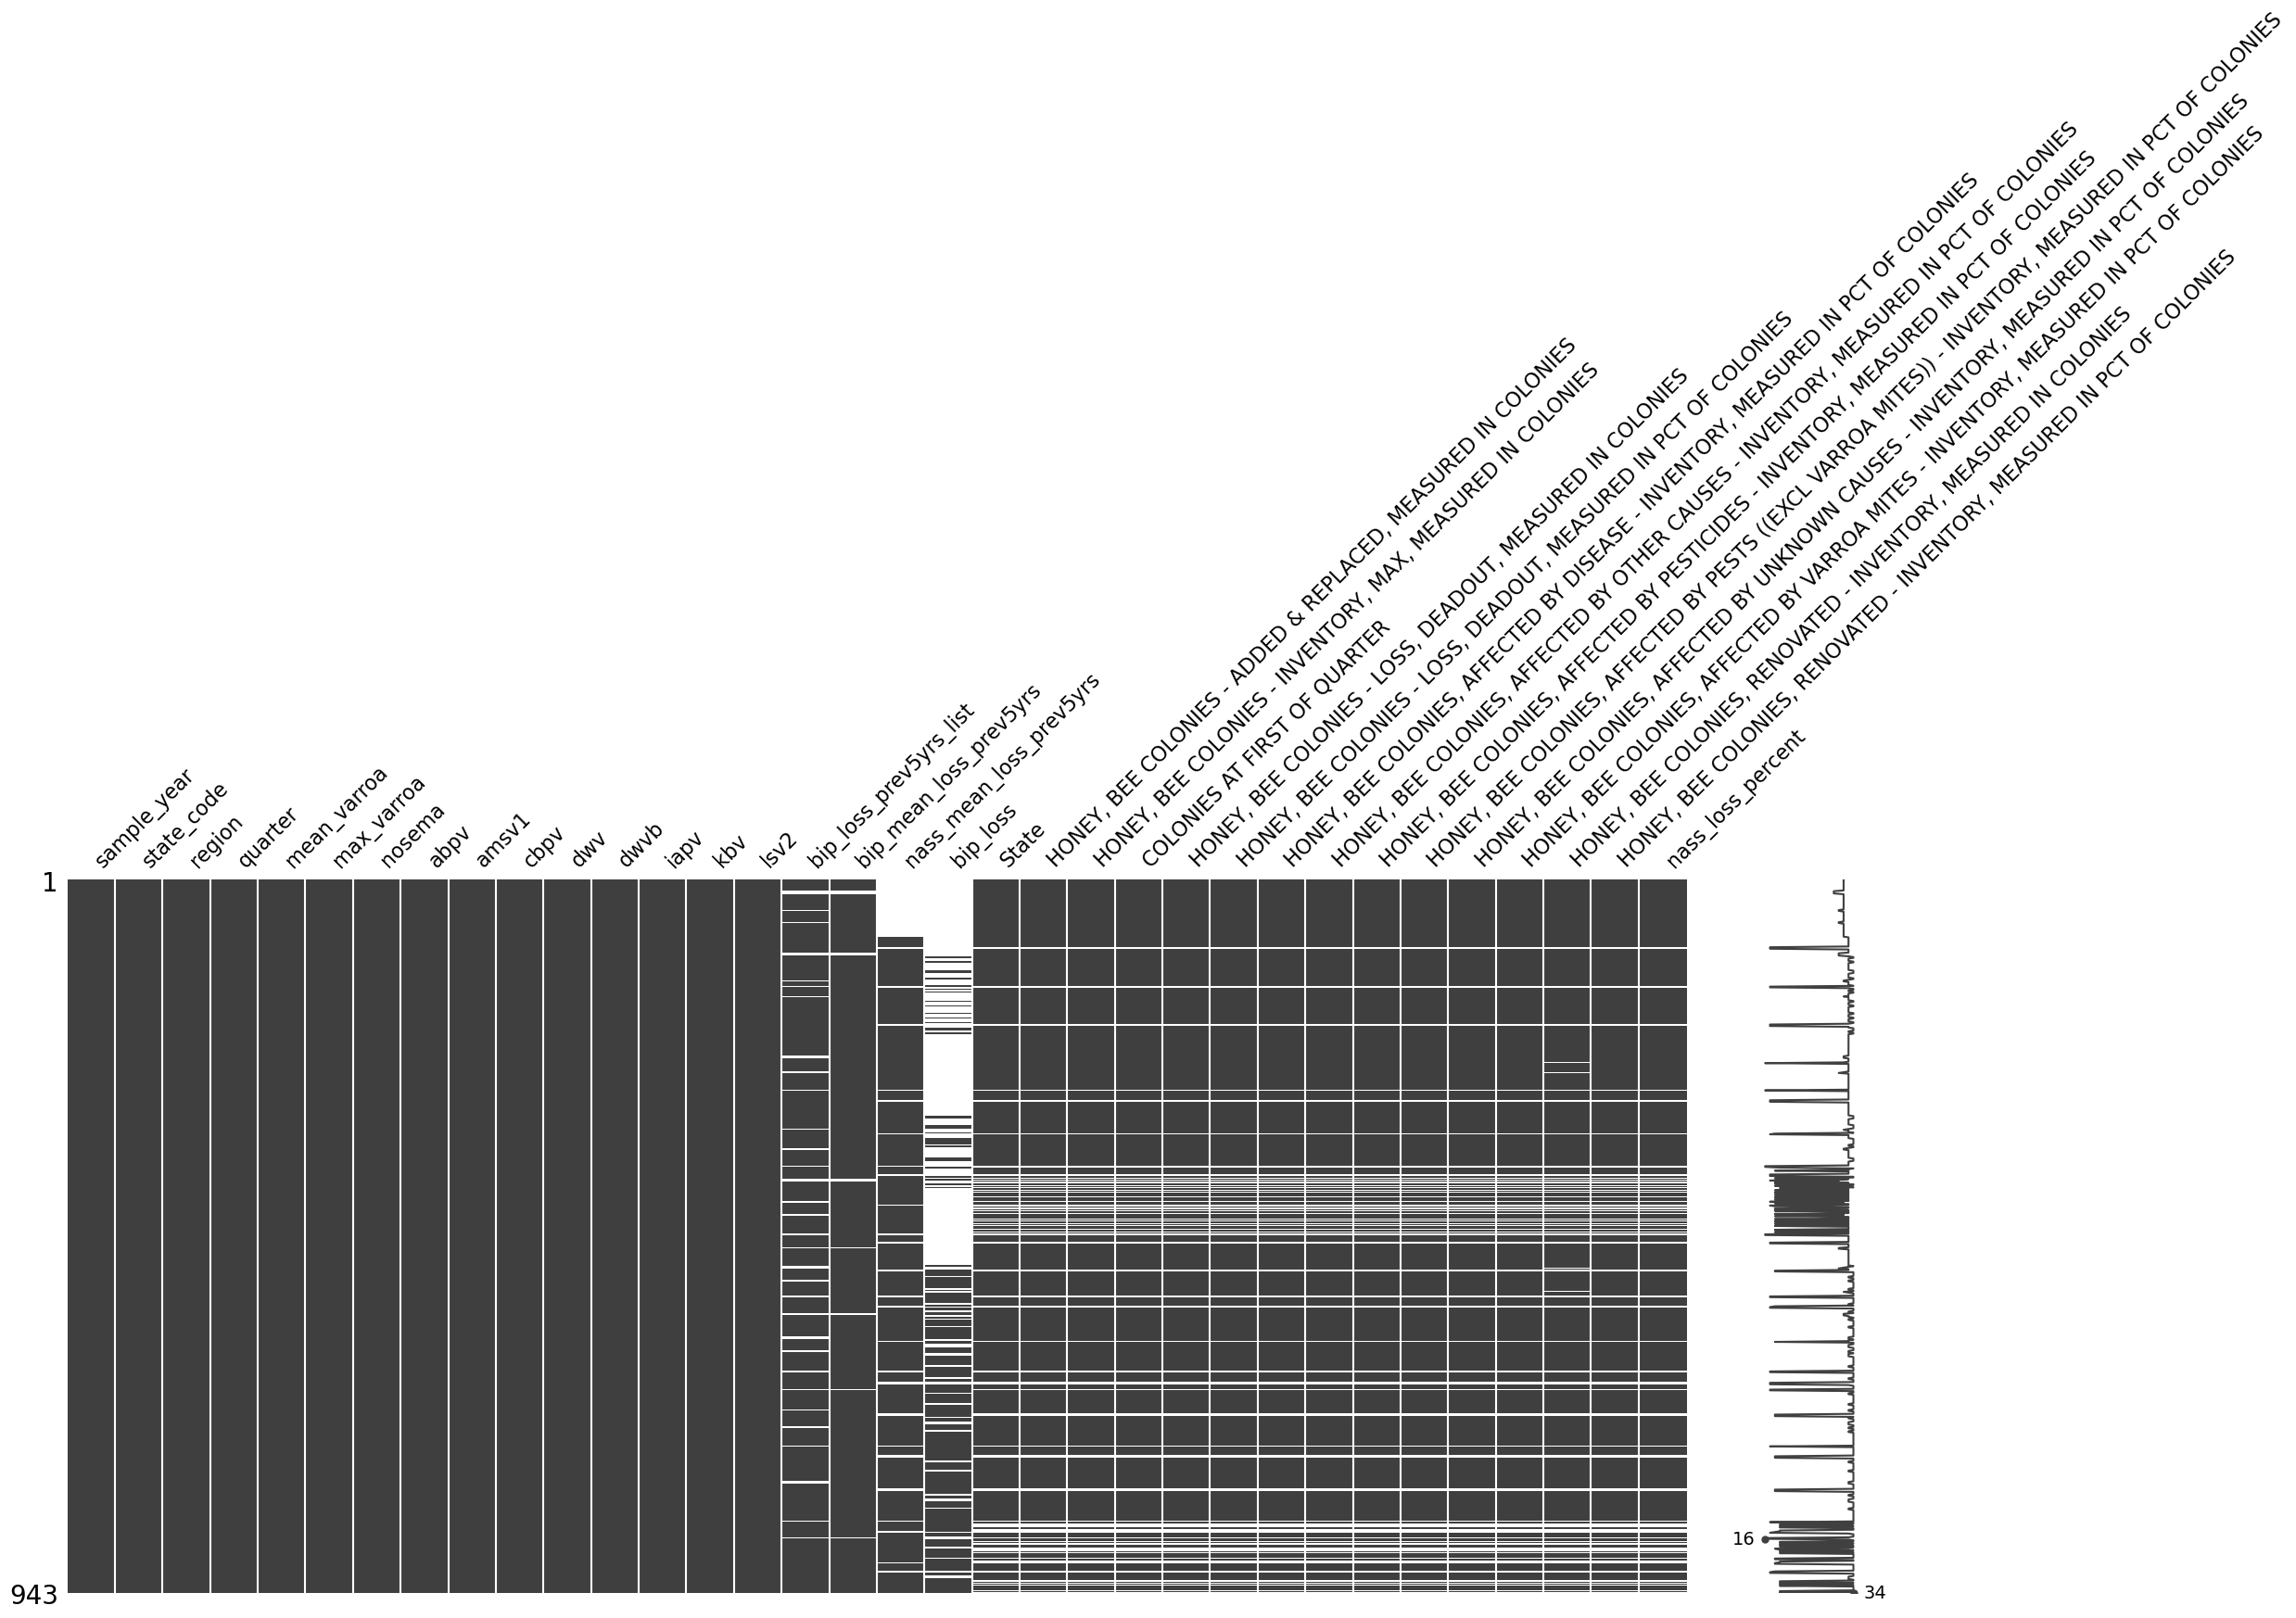

In [112]:
import missingno as msno
msno.matrix(merged_df)
plt.show()

We would like to briefly compare the loss values for the BIP and NASS. 

(np.float64(-0.029877495513506235),
 np.float64(0.847427405783631),
 np.float64(-0.029877495513506235),
 np.float64(0.847427405783631))

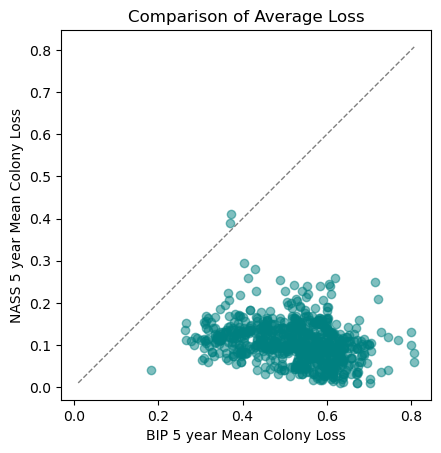

In [113]:
merged_nonan=merged_df.dropna(subset=['bip_mean_loss_prev5yrs','nass_mean_loss_prev5yrs'])

plt.scatter(merged_nonan['bip_mean_loss_prev5yrs'], merged_nonan['nass_mean_loss_prev5yrs'], color='teal', alpha=0.5)


# Add x=y reference line
min_val = min(merged_nonan[['bip_mean_loss_prev5yrs','nass_mean_loss_prev5yrs']].min())
max_val = max(merged_nonan[['bip_mean_loss_prev5yrs','nass_mean_loss_prev5yrs']].max())
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)

# Labels and title
plt.xlabel('BIP 5 year Mean Colony Loss')
plt.ylabel('NASS 5 year Mean Colony Loss')
plt.title('Comparison of Average Loss')
plt.axis('square')

(np.float64(-0.04745726186142196),
 np.float64(0.9966024990898612),
 np.float64(-0.04745726186142196),
 np.float64(0.9966024990898612))

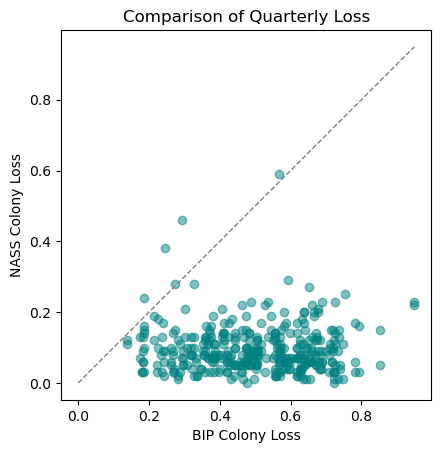

In [114]:
plt.scatter(merged_nonan['bip_loss'], merged_nonan['nass_loss_percent'], color='teal', alpha=0.5)


# Add x=y reference line
min_val = min(merged_nonan[['bip_loss','nass_loss_percent']].min())
max_val = max(merged_nonan[['bip_loss','nass_loss_percent']].max())
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)

# Labels and title
plt.xlabel('BIP Colony Loss')
plt.ylabel('NASS Colony Loss')
plt.title('Comparison of Quarterly Loss')
plt.axis('square')

## Add target variable
Y = 1 if the current loss > avg/median quarterly loss and 0 otherwise.

In [ ]:
merged_df['target_nass'] = 

## Incorporate Weather Data 

In [115]:
weather_df=pd.read_csv('../data/normalized_weather_data.csv')

In [119]:
weather_df.sample(10)


,ID_state,ID_year,Quarter,pcpn,tmax,tmin,tmpc
2064,49,2015,Q1,0.518378,0.713187,0.758750,0.741469
184,5,2018,Q1,0.293574,0.424542,0.295417,0.359695
1489,35,2021,Q4,0.528338,0.463004,0.466667,0.463268
948,23,2015,Q3,0.559877,0.848718,0.864167,0.866720
444,11,2018,Q3,0.540432,0.841026,0.854167,0.857086
1352,32,2019,Q4,0.315864,0.306593,0.293750,0.294259
975,23,2022,Q2,0.546834,0.753114,0.738333,0.753513
1606,38,2018,Q4,0.660422,0.644689,0.639583,0.645925
355,9,2017,Q4,0.409533,0.676923,0.645833,0.667202
713,17,2021,Q2,0.420678,0.639560,0.586250,0.618226


In [127]:
import us

In [143]:
states = [s for s in us.states.STATES] 
states_sorted = sorted(states, key=lambda s: s.name)
num_to_abbr = {i+1: state.abbr for i, state in enumerate(states_sorted)}

weather_df['state_code'] = weather_df['ID_state'].map(num_to_abbr)



In [144]:
weather_df.sample(10)

,ID_state,sample_year,quarter,pcpn,tmax,tmin,tmpc,state,state_code
1486,35,2021,Q1,0.482808,0.410256,0.404583,0.405058,OH,OH
45,2,2015,Q3,0.353806,0.926007,0.875000,0.914091,AK,AK
1401,33,2021,Q2,0.485179,0.710256,0.683333,0.703332,NC,NC
507,12,2023,Q3,0.473797,0.823077,0.816250,0.829386,ID,ID
707,17,2019,Q4,0.547783,0.371062,0.375000,0.369330,KY,KY
1515,36,2017,Q3,0.511738,0.780952,0.775833,0.787234,OK,OK
2013,47,2023,Q4,0.372303,0.436264,0.447917,0.439984,WA,WA
2007,47,2022,Q2,0.471188,0.630769,0.607500,0.623043,WA,WA
273,7,2018,Q4,0.622480,0.555311,0.573333,0.565235,CT,CT
1771,42,2017,Q1,0.365900,0.429304,0.386250,0.406263,TN,TN


In [145]:
weather_df = weather_df.rename(columns={
    'ID_year': 'sample_year',
    'Quarter': 'quarter'
})

merged_weather_df = pd.merge(
    merged_df,
    weather_df,
    on=['sample_year', 'quarter', 'state_code'],
    how='left'
)

In [146]:
merged_weather_df.to_csv("../data/interim/combined_nass_aphis_weather_1028_df.csv", index=False)
